In [1]:
# @title Configuration
BATCH_SIZE = 4  # @param {type:"integer"}
SEED = 42  # @param {type:"integer"}
NUM_EPOCHS = 1  # @param {type:"integer"}
N_ITERATIONS = 500  # @param {type:"integer"}
N_FREQ_EVAL = 50  # @param {type:"integer"}
LEARNING_RATE = 1e-3  # @param {type:"number"}
MAX_LENGTH = 256  # @param {type:"integer"}
DATASET_NAME = "tqa"  # @param {type:"string"}
MAX_SAMPLES = 1000  # @param {type:"integer"}

## 📦 Packages and Basic Setup
---

In [2]:
%%capture
!pip install --upgrade jax jaxlib optax transformers datasets grain pillow jaxtyping

In [3]:
import os
import sys

# Clone the repo and add it to the path
if not os.path.exists("nanoVLMJAX"):
    !git clone -b add-notebook https://github.com/SauravMaheshkar/nanoVLMJAX.git

sys.path.insert(0, "nanoVLMJAX")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from rich.progress import track
from transformers import AutoProcessor, AutoTokenizer

Cloning into 'nanoVLMJAX'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 116 (delta 38), reused 98 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 63.72 KiB | 4.55 MiB/s, done.
Resolving deltas: 100% (38/38), done.


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:91: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [4]:
jax.devices()

[TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]

In [5]:
from jax.experimental import mesh_utils
from jax.sharding import Mesh

devices = mesh_utils.create_device_mesh((jax.device_count(), 1))
mesh = Mesh(devices, ("batch", "model"))
mesh

Mesh(axis_sizes=(1, 1), axis_names=('batch', 'model'), axis_types=(Auto, Auto))

## 💿 The Dataset
---

In [ ]:
from src.data.datasets import VLMDataset, load_cauldron
from src.data.loss import get_prefix_len, prepare_training_sample
from src.input_pipeline import build_grain_pipeline, iter_batches

tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")

if getattr(tokenizer, "chat_template", None) is None:
    tokenizer.chat_template = (
        "{% for message in messages %}{{ message['content'] }}\n{% endfor %}"
    )
prefix_len = get_prefix_len(tokenizer)

hf_dataset = load_cauldron("HuggingFaceM4/the_cauldron", DATASET_NAME, split="train")
if MAX_SAMPLES is not None:
    hf_dataset = hf_dataset.select(range(min(MAX_SAMPLES, len(hf_dataset))))

# Simple train/val split
val_size = min(100, len(hf_dataset) // 5)
val_hf = hf_dataset.select(range(val_size))
train_hf = hf_dataset.select(range(val_size, len(hf_dataset)))

train_dataset = VLMDataset(train_hf, processor)
val_dataset = VLMDataset(val_hf, processor)

train_iter = build_grain_pipeline(train_dataset, shuffle=True, seed=SEED)
val_iter = build_grain_pipeline(val_dataset, shuffle=False, seed=SEED)

image_token_id = tokenizer.convert_tokens_to_ids("<image>")
if image_token_id is None or image_token_id <= 0:
    # Fallback: use a dummy image token id for from-scratch training
    image_token_id = 10

mp_image_token_length = 64


def tokenize_sample(sample):
    messages = sample.get("messages", [])
    if not messages:
        return None
    try:
        inputs = prepare_training_sample(tokenizer, messages, prefix_len)
    except Exception:
        return None

    images = sample.get("images", [])
    if images and image_token_id is not None and image_token_id > 0:
        num_image_tokens = mp_image_token_length
        image_ids = np.full(num_image_tokens, image_token_id, dtype=np.int32)
        image_mask = np.ones(num_image_tokens, dtype=np.int32)
        image_labels = np.full(num_image_tokens, -100, dtype=np.int32)

        inputs["input_ids"] = np.concatenate([image_ids, inputs["input_ids"]])
        inputs["attention_mask"] = np.concatenate(
            [image_mask, inputs["attention_mask"]]
        )
        inputs["labels"] = np.concatenate([image_labels, inputs["labels"]])

    return {
        "input_ids": inputs["input_ids"],
        "attention_mask": inputs["attention_mask"],
        "labels": inputs["labels"],
        "images": images,
    }


pad_token_id = int(tokenizer.pad_token_id) if tokenizer.pad_token_id is not None else 0
print(
    f"Train samples: {len(train_hf)}"
    f"Val samples: {len(val_hf)}, image_token_id={image_token_id}"
)

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

tqa/train-00000-of-00001-c15be8aed9c9386(…):   0%|          | 0.00/378M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1493 [00:00<?, ? examples/s]

Train samples: 900, Val samples: 100, image_token_id=10


## ✍️ Model Architecture
---

In [7]:
from src.models.vision_language_model import VisionLanguageModel, VLMConfig, vlm_forward

# Tiny VLM config for demonstration
vlm_cfg = VLMConfig(
    vit_hidden_dim=128,
    vit_inter_dim=256,
    vit_patch_size=16,
    vit_img_size=224,
    vit_n_heads=4,
    vit_dropout=0.0,
    vit_n_blocks=2,
    vit_ln_eps=1e-6,
    vit_cls_flag=False,
    lm_hidden_dim=128,
    lm_inter_dim=256,
    lm_rms_eps=1e-5,
    lm_re_base=100000,
    lm_max_position_embeddings=512,
    lm_vocab_size=len(tokenizer),
    lm_n_heads=4,
    lm_n_kv_heads=2,
    lm_dropout=0.0,
    lm_n_layers=2,
    lm_attn_scaling=1.0,
    lm_use_tokens=False,
    lm_tie_weights=True,
    lm_attention_bias=False,
    mp_pixel_shuffle_factor=2,
    mp_image_token_length=mp_image_token_length,
    image_token_id=image_token_id,
    dtype=jnp.float32,
)


class ShardingRule:
    batch = "batch"
    seq = None
    hidden = "model"
    tp = "model"
    kernel_h = None
    kernel_w = None
    in_channels = None
    out_channels = "model"


rng = jax.random.PRNGKey(SEED)
init_key, rng = jax.random.split(rng)

params = VisionLanguageModel.init(init_key, mesh, ShardingRule, vlm_cfg)
num_params = sum(p.size for p in jax.tree.leaves(params))
print(f"Total number of parameters: {num_params:_}")

Total number of parameters: 13_331_600



## 🏃 Train !!
---

In [10]:
def compute_loss(logits, labels, attention_mask):
    valid_mask = (labels != -100) & (attention_mask == 1)
    safe_labels = jnp.where(valid_mask, labels, 0)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, safe_labels)
    loss = jnp.where(valid_mask, loss, 0.0)
    return loss.sum() / jnp.maximum(valid_mask.sum(), 1.0)


def loss_fn(params, batch, key):
    logits = vlm_forward(
        params,
        batch["input_ids"],
        batch.get("images"),
        key,
        batch.get("attention_mask"),
    )
    loss = compute_loss(logits, batch["labels"], batch["attention_mask"])
    return loss, logits


@jax.jit
def _compute_grads(params, batch, key):
    grad_fn = jax.value_and_grad(lambda p: loss_fn(p, batch, key)[0])
    return grad_fn(params)


def train_step(params, opt_state, batch, key, optimizer):
    loss, grads = _compute_grads(params, batch, key)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


@jax.jit
def eval_step(params, batch):
    loss, _ = loss_fn(params, batch, None)
    return loss


optimizer = optax.adamw(LEARNING_RATE)
opt_state = optimizer.init(params)

metrics_history = {
    "train_loss": [],
    "val_loss": [],
}

In [11]:
for epoch in range(NUM_EPOCHS):
    train_batch_iter = iter_batches(
        train_iter,
        tokenize_sample,
        batch_size=BATCH_SIZE,
        pad_token_id=pad_token_id,
        max_length=MAX_LENGTH,
    )

    for i in track(range(N_ITERATIONS)):
        try:
            batch = next(train_batch_iter)
        except StopIteration:
            break

        jax_batch = {
            k: jnp.array(v) if isinstance(v, np.ndarray) else v
            for k, v in batch.items()
        }
        rng, step_key = jax.random.split(rng)
        params, opt_state, loss = train_step(
            params, opt_state, jax_batch, step_key, optimizer
        )

        if i % N_FREQ_EVAL == 0:
            metrics_history["train_loss"].append(float(loss))
            print(f"Iteration {i}, Loss: {metrics_history['train_loss'][-1]:.4f}")

            # Quick validation
            val_batch_iter = iter_batches(
                val_iter,
                tokenize_sample,
                batch_size=BATCH_SIZE,
                pad_token_id=pad_token_id,
                max_length=MAX_LENGTH,
            )
            val_losses = []
            for _ in range(8):
                try:
                    val_batch = next(val_batch_iter)
                except StopIteration:
                    break
                jax_val_batch = {
                    k: jnp.array(v) if isinstance(v, np.ndarray) else v
                    for k, v in val_batch.items()
                }
                val_loss = eval_step(params, jax_val_batch)
                val_losses.append(float(val_loss))
            if val_losses:
                avg_val_loss = sum(val_losses) / len(val_losses)
                metrics_history["val_loss"].append(avg_val_loss)
                print(f"Iteration {i}, Val Loss: {avg_val_loss:.4f}")

Output()

Iteration 0, Loss: 11.4611

Iteration 0, Val Loss: 11.1816

Iteration 50, Loss: 6.9534

Iteration 50, Val Loss: 7.8779

Iteration 100, Loss: 8.4403

Iteration 100, Val Loss: 7.5965

Iteration 150, Loss: 5.7676

Iteration 150, Val Loss: 7.3660

## 📉 Loss Curves
---

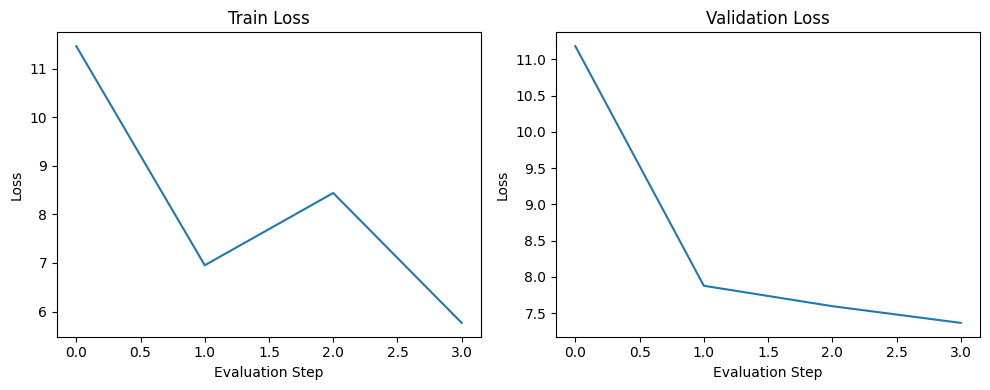

In [12]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(metrics_history["train_loss"])
plt.title("Train Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(metrics_history["val_loss"])
plt.title("Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

## 🔮 Generation (Greedy Sampling)
---

In [13]:
def greedy_generate(params, prompt_ids, max_new_tokens=20):
    ids = list(prompt_ids)
    for _ in range(max_new_tokens):
        input_ids = jnp.array([ids], dtype=jnp.int32)
        logits = vlm_forward(params, input_ids, images=None, key=None)
        next_token = int(jnp.argmax(logits[:, -1, :], axis=-1)[0])
        ids.append(next_token)
    return ids


# Simple text-only prompt (model is tiny, so output will be random-ish)
prompt = "Question: What is the capital of France? Answer:"
prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
generated_ids = greedy_generate(params, prompt_ids, max_new_tokens=10)
print(tokenizer.decode(generated_ids))

Question: What is the capital of France? Answer: the the the the the the the the the the
